In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score

PALETTE = {
    # binary
    "PD":       "#E24B4A",   
    "Healthy":  "#378ADD",  
    # classifiers
    "SVM":      "#7F77DD",   
    "HGB":      "#1D9E75",   
    "LR":       "#BA7517",   
    "RF":       "#B07FC8",   
    # feature subsets
    "All":      "#D4537E",  
    "JS":       "#639922",  
}
ALPHA_WITH    = 1.00   # bars/markers with outliers
ALPHA_WITHOUT = 0.45   # bars/markers without outliers

plt.rcParams.update({
    "figure.dpi":      150,
    "font.family":     "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

COL_OUTLIER = '#f5a623'   # orange, outlier markers

In [2]:
df = pd.read_csv('../data/2025_parkinsons.csv')
df['subject'] = df['name'].str.rsplit('_', n=1).str[0]
df = df.dropna().reset_index(drop=True)

features = [c for c in df.columns if c not in ['name', 'subject', 'status']]

print(f'Recordings after dropping NaN: {len(df)}')
print(f'PD: {(df["status"]==1).sum()},  Healthy: {(df["status"]==0).sum()}')
print(f'Features: {len(features)}')

Recordings after dropping NaN: 185
PD: 141,  Healthy: 44
Features: 22


In [3]:
# IQR outlier flagging 
def iqr_flag(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

iqr_flags = pd.DataFrame({f: iqr_flag(df[f]) for f in features}, index=df.index)
df['iqr_outlier_count'] = iqr_flags.sum(axis=1)

# Z-score outlier flagging
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
z_scores = np.abs(X_scaled)
df['zscore_max']     = z_scores.max(axis=1)
df['zscore_outlier'] = (z_scores > 3).any(axis=1)

print('IQR outlier summary')
print(f"Flagged in ≥1 feature:  {(df['iqr_outlier_count'] > 0).sum()}")
print(f"Flagged in ≥3 features: {(df['iqr_outlier_count'] >= 3).sum()}")
print()
print('Z-score outlier summary (|z| > 3 in any feature)')
print(f"Total flagged: {df['zscore_outlier'].sum()}")
print()
print('Recordings flagged in ≥3 features (IQR):')
top = (df[df['iqr_outlier_count'] >= 3]
       [['name', 'status', 'iqr_outlier_count', 'zscore_max']]
       .sort_values('iqr_outlier_count', ascending=False))
print(top.to_string(index=False))

IQR outlier summary
Flagged in ≥1 feature:  48
Flagged in ≥3 features: 15

Z-score outlier summary (|z| > 3 in any feature)
Total flagged: 14

Recordings flagged in ≥3 features (IQR):
          name  status  iqr_outlier_count  zscore_max
phon_R01_S35_6     1.0                 16    6.622236
phon_R01_S35_7     1.0                 15    4.834390
phon_R01_S24_6     1.0                 14    5.678906
phon_R01_S24_4     1.0                 13    7.028798
phon_R01_S35_1     1.0                 10    3.718892
phon_R01_S35_3     1.0                  9    2.559891
phon_R01_S35_4     1.0                  9    3.956263
phon_R01_S24_3     1.0                  7    3.445457
phon_R01_S35_5     1.0                  7    2.882987
phon_R01_S24_5     1.0                  6    2.253846
phon_R01_S22_1     1.0                  6    2.758355
phon_R01_S35_2     1.0                  6    2.288250
phon_R01_S37_5     1.0                  6    3.012499
phon_R01_S24_2     1.0                  4    1.884279
phon_R

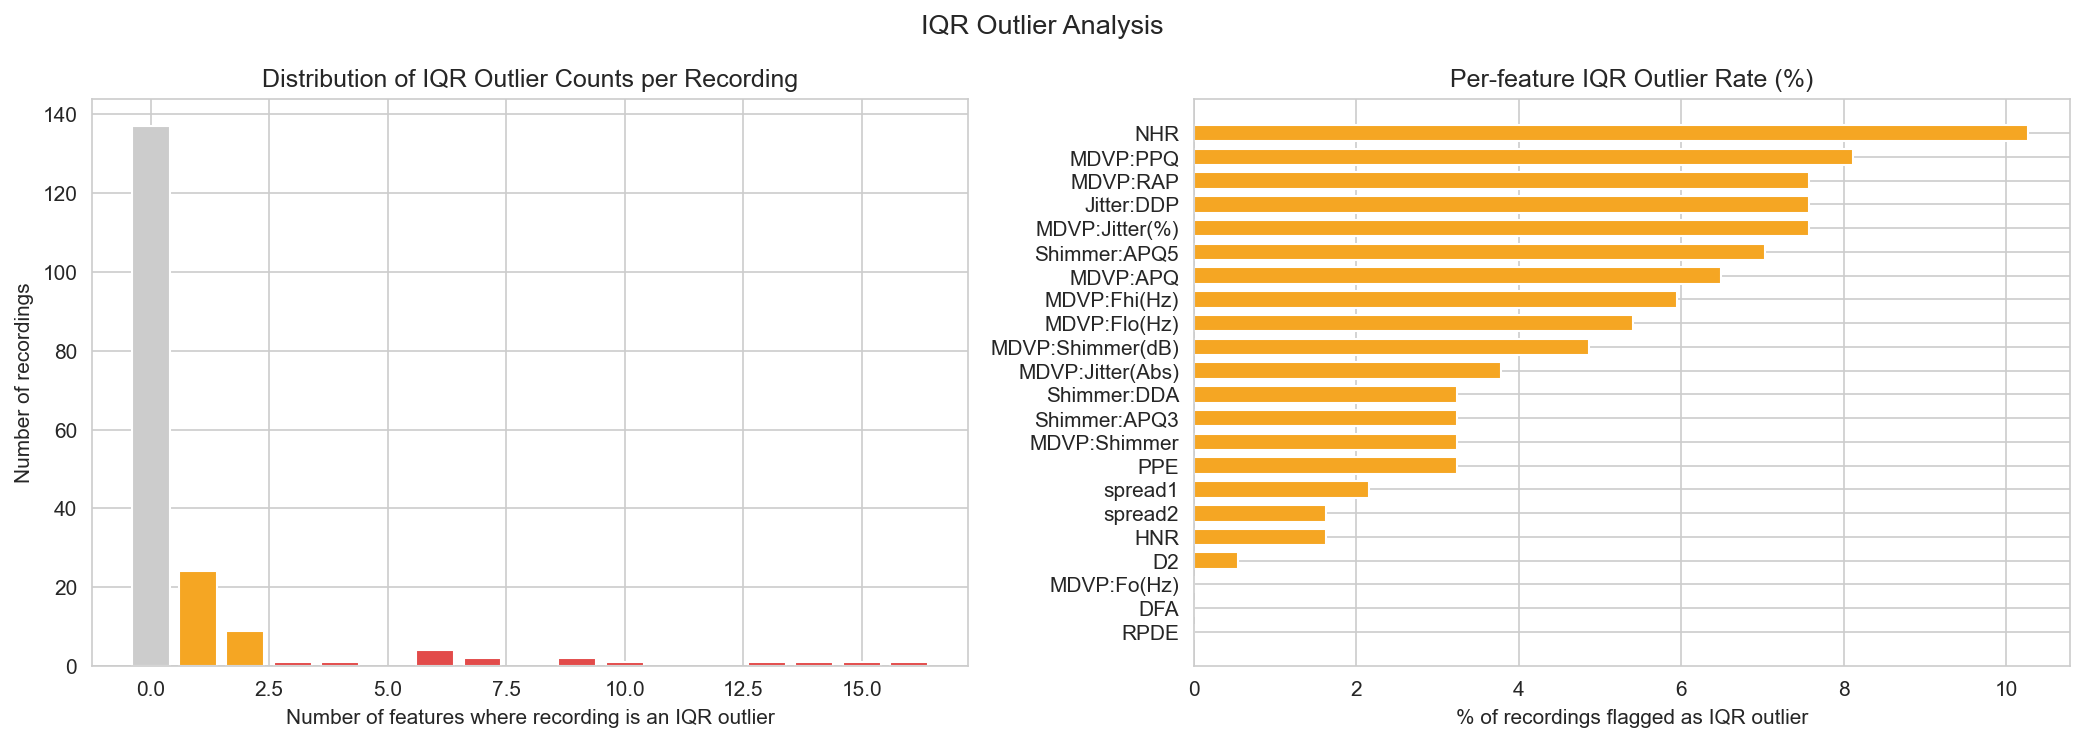

In [4]:
# IQR outlier visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of how many features each recording is flagged in
ax = axes[0]
counts = df['iqr_outlier_count'].value_counts().sort_index()
bar_colors = ['#cccccc' if i == 0 else (COL_OUTLIER if i < 3 else PALETTE["PD"]) for i in counts.index]
ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white')
ax.set_xlabel('Number of features where recording is an IQR outlier')
ax.set_ylabel('Number of recordings')
ax.set_title('Distribution of IQR Outlier Counts per Recording')

# Right: per-feature IQR outlier rate
ax2 = axes[1]
outlier_rates = iqr_flags.mean().sort_values(ascending=False) * 100
ax2.barh(outlier_rates.index, outlier_rates.values,
         color=COL_OUTLIER, edgecolor='white', height=0.7)
ax2.set_xlabel('% of recordings flagged as IQR outlier')
ax2.set_title('Per-feature IQR Outlier Rate (%)')
ax2.invert_yaxis()

fig.suptitle('IQR Outlier Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('plots/outlier_iqr.png', dpi=200, bbox_inches='tight')
plt.show()

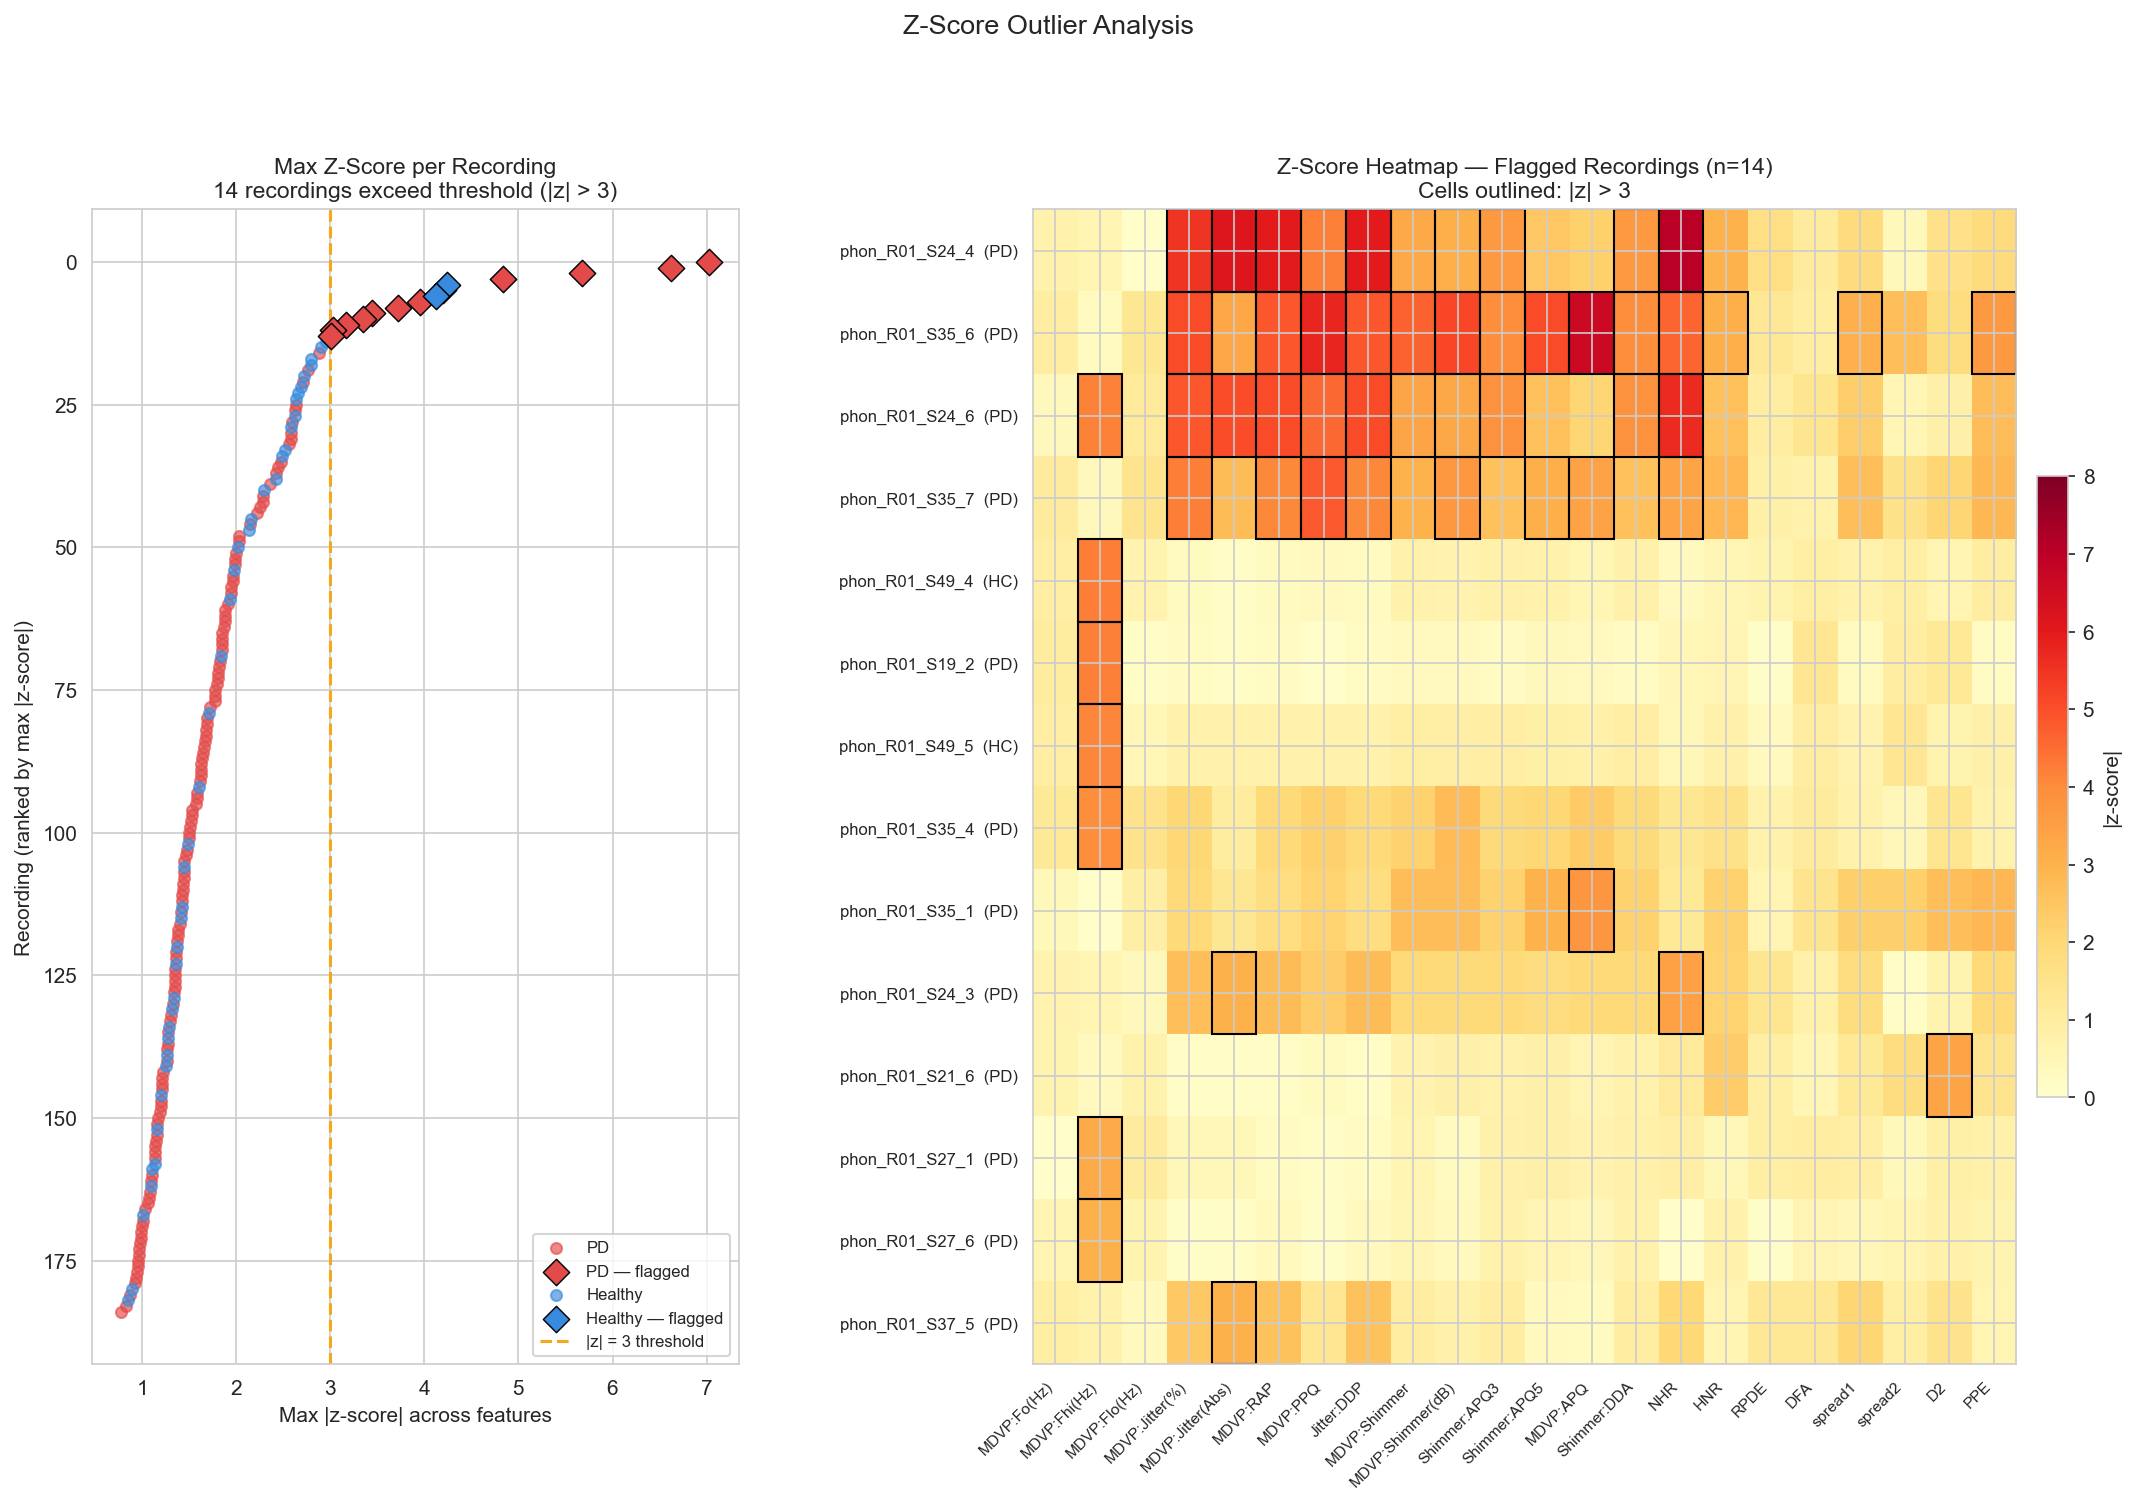

In [5]:
# Z-score outlier visualisation
z_df = pd.DataFrame(z_scores, columns=features, index=df.index)

fig = plt.figure(figsize=(17, 10))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.35)
ax_left  = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1])

# Left: sorted max |z-score| per recording 
df_sorted = df.sort_values('zscore_max', ascending=False).reset_index(drop=True)
for g, label, color in [(1, 'PD', PALETTE["PD"]), (0, 'Healthy', PALETTE["Healthy"])]:
    m     = df_sorted['status'] == g
    m_out = m & df_sorted['zscore_outlier']
    m_ok  = m & ~df_sorted['zscore_outlier']
    ax_left.scatter(df_sorted.loc[m_ok,  'zscore_max'], df_sorted.index[m_ok],
                    c=color, s=28, alpha=0.65, label=label, zorder=3)
    ax_left.scatter(df_sorted.loc[m_out, 'zscore_max'], df_sorted.index[m_out],
                    c=color, s=80, marker='D', edgecolors='black', linewidths=0.7,
                    label=f'{label} — flagged', zorder=4)

ax_left.axvline(3, color=COL_OUTLIER, linestyle='--', linewidth=1.5,
                label='|z| = 3 threshold', zorder=2)
ax_left.set_xlabel('Max |z-score| across features', fontsize=10)
ax_left.set_ylabel('Recording (ranked by max |z-score|)', fontsize=10)
ax_left.set_title(
    f'Max Z-Score per Recording\n'
    f'{df["zscore_outlier"].sum()} recordings exceed threshold (|z| > 3)',
    fontsize=11
)
ax_left.legend(fontsize=8, loc='lower right')
ax_left.invert_yaxis()

# Right: heatmap of |z-scores| for flagged recordings
outlier_idx = df.index[df['zscore_outlier']]
z_out = z_df.loc[outlier_idx].copy()
row_order = z_out.max(axis=1).sort_values(ascending=False).index
z_out = z_out.loc[row_order]

row_labels = [
    f"{df.loc[i, 'name']}  ({'PD' if df.loc[i, 'status'] == 1 else 'HC'})"
    for i in row_order
]

im = ax_right.imshow(z_out.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=8)
ax_right.set_xticks(range(len(features)))
ax_right.set_xticklabels(features, rotation=45, ha='right', fontsize=7.5)
ax_right.set_yticks(range(len(row_order)))
ax_right.set_yticklabels(row_labels, fontsize=8)

# box cells that exceed threshold
for i_r in range(z_out.shape[0]):
    for i_c in range(z_out.shape[1]):
        if z_out.values[i_r, i_c] > 3:
            ax_right.add_patch(plt.Rectangle(
                (i_c - 0.5, i_r - 0.5), 1, 1,
                fill=False, edgecolor='black', linewidth=1.0
            ))

plt.colorbar(im, ax=ax_right, label='|z-score|', fraction=0.03, pad=0.02)
ax_right.set_title(
    f'Z-Score Heatmap — Flagged Recordings (n={len(row_order)})\n'
    'Cells outlined: |z| > 3',
    fontsize=11
)

fig.suptitle('Z-Score Outlier Analysis', fontsize=13, y=1.01)
plt.savefig('plots/outlier_zscore.png', dpi=200, bbox_inches='tight')
plt.show()

In [6]:
# PCA + per-group Mahalanobis distance for multivariate outlier detection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pc1'] = X_pca[:, 0]
df['pc2'] = X_pca[:, 1]

def mahal_dist(X):
    mean    = X.mean(axis=0)
    inv_cov = np.linalg.pinv(np.cov(X.T))
    diff    = X - mean
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))

df['mahal'] = 0.0
for g in [0, 1]:
    mask = df['status'] == g
    df.loc[mask, 'mahal'] = mahal_dist(X_pca[mask.values])

threshold = np.percentile(df['mahal'], 97.5)
df['mahal_outlier'] = df['mahal'] > threshold

# Euclidean distance from group centroid in PCA space (for comparison)
def eucl_dist(X):
    return np.sqrt(((X - X.mean(axis=0)) ** 2).sum(axis=1))

df['eucl'] = 0.0
for g in [0, 1]:
    mask = df['status'] == g
    df.loc[mask, 'eucl'] = eucl_dist(X_pca[mask.values])

eucl_threshold   = np.percentile(df['eucl'], 97.5)
df['eucl_outlier'] = df['eucl'] > eucl_threshold

df['pca_outlier'] = df['mahal_outlier']  # alias used in combined flag below


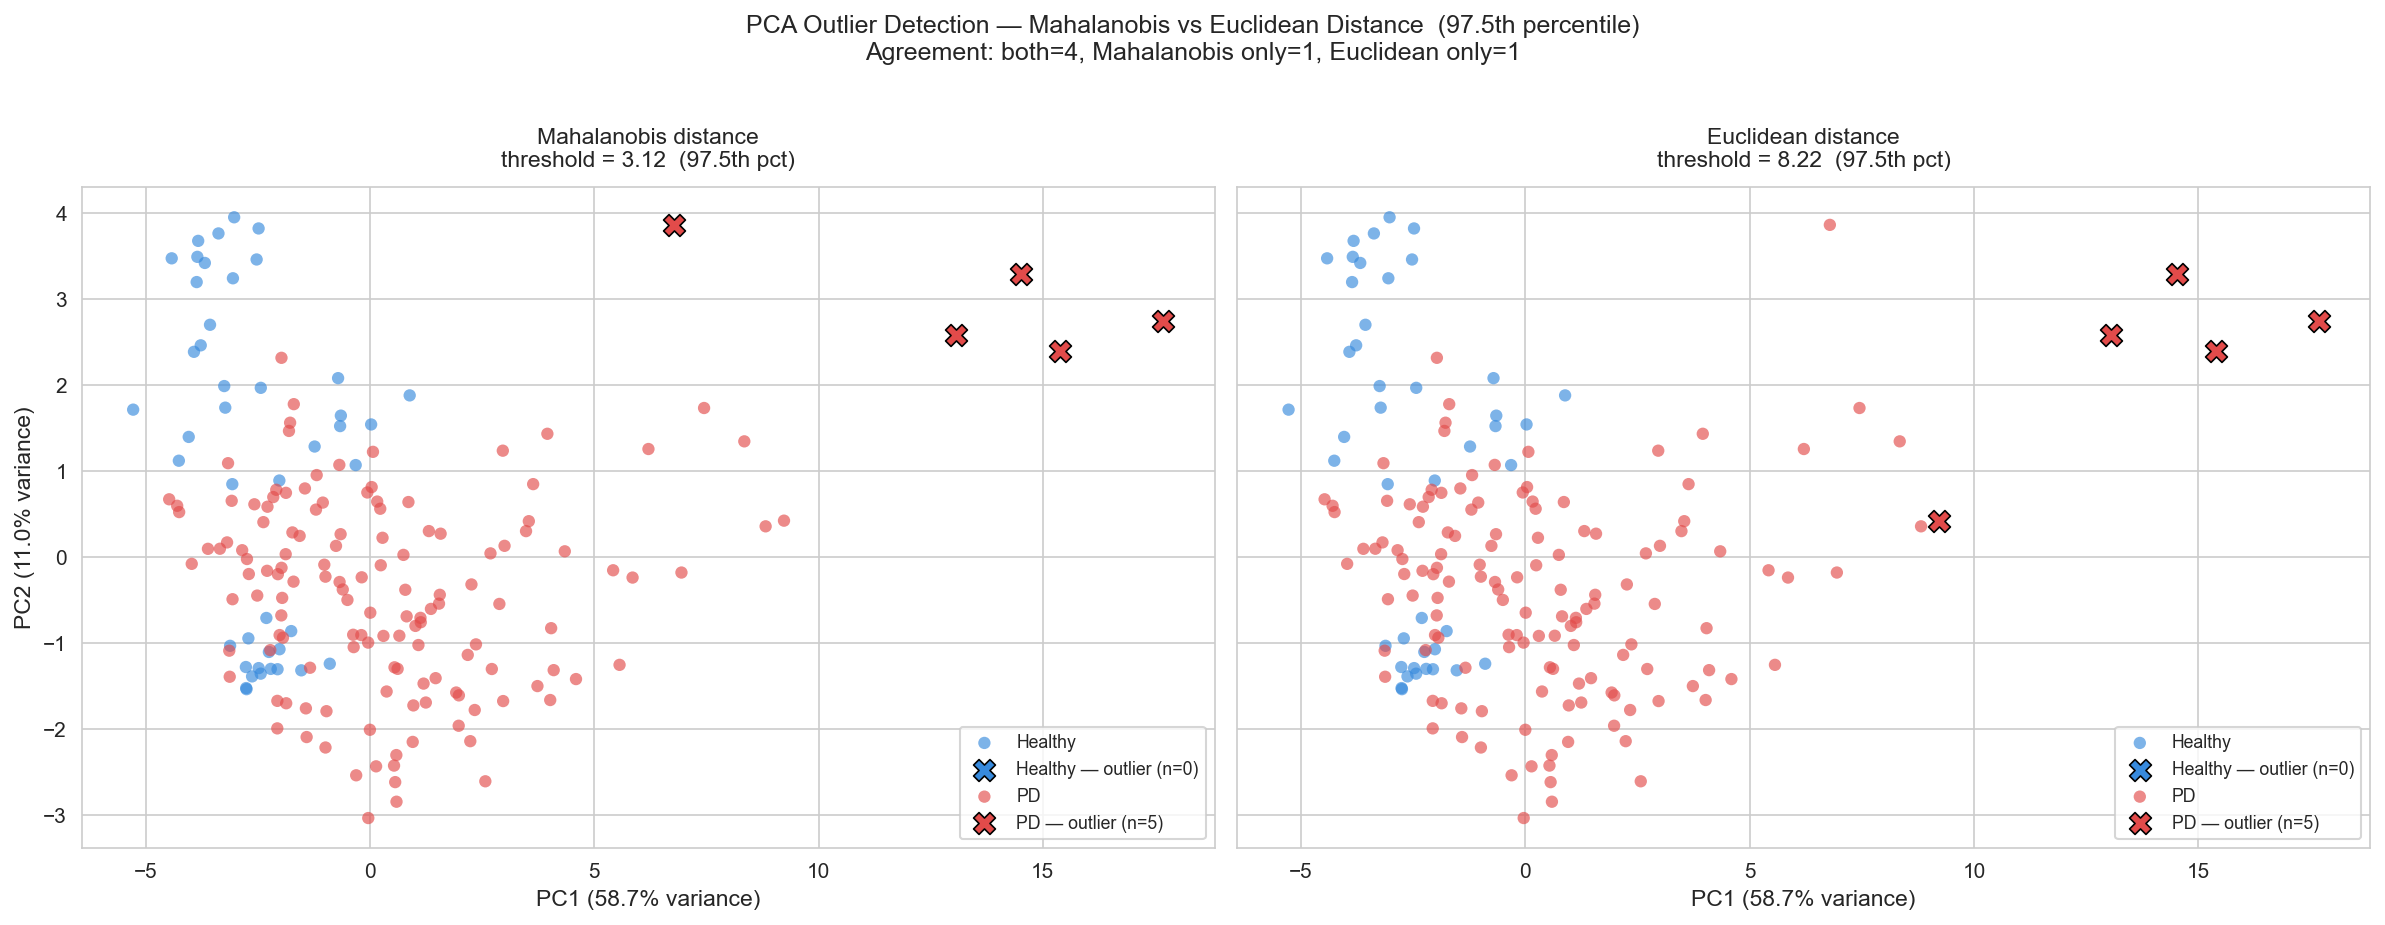

Mahalanobis outliers : 5
Euclidean outliers: 5
Flagged by both: 4
Mahalanobis only: 1 (ellipsoidal -> accounts for feature correlation)
Euclidean only: 1 (spherical -> treats all directions equally)


In [7]:
# Side-by-side: Mahalanobis (left) vs Euclidean (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

methods = [
    ('mahal_outlier',  'mahal',  f'Mahalanobis distance\nthreshold = {threshold:.2f}  (97.5th pct)'),
    ('eucl_outlier', 'eucl',   f'Euclidean distance\nthreshold = {eucl_threshold:.2f}  (97.5th pct)'),
]

for ax, (outlier_col, dist_col, subtitle) in zip(axes, methods):
    for g, label, color in [(0, 'Healthy', PALETTE["Healthy"]), (1, 'PD', PALETTE["PD"])]:
        m_ok  = (df['status'] == g) & ~df[outlier_col]
        m_out = (df['status'] == g) &  df[outlier_col]
        ax.scatter(df.loc[m_ok,  'pc1'], df.loc[m_ok,  'pc2'],
                   c=color, label=label, alpha=0.65, s=35, edgecolors='none')
        ax.scatter(df.loc[m_out, 'pc1'], df.loc[m_out, 'pc2'],
                   c=color, marker='X', s=110, edgecolors='black', linewidths=0.8,
                   label=f'{label} — outlier (n={int(m_out.sum())})')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    ax.set_title(subtitle, fontsize=11, pad=10)
    ax.legend(fontsize=8.5)

axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)

# Agreement summary between the two methods
agree_both = (df['mahal_outlier'] & df['eucl_outlier']).sum()
only_mahal = (df['mahal_outlier'] & ~df['eucl_outlier']).sum()
only_eucl  = (~df['mahal_outlier'] & df['eucl_outlier']).sum()
fig.suptitle(
    'PCA Outlier Detection — Mahalanobis vs Euclidean Distance  (97.5th percentile)\n'
    f'Agreement: both={agree_both}, Mahalanobis only={only_mahal}, Euclidean only={only_eucl}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('plots/outlier_pca.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Mahalanobis outliers : {df['pca_outlier'].sum()}")
print(f"Euclidean outliers: {df['eucl_outlier'].sum()}")
print(f"Flagged by both: {agree_both}")
print(f"Mahalanobis only: {only_mahal} (ellipsoidal -> accounts for feature correlation)")
print(f"Euclidean only: {only_eucl} (spherical -> treats all directions equally)")

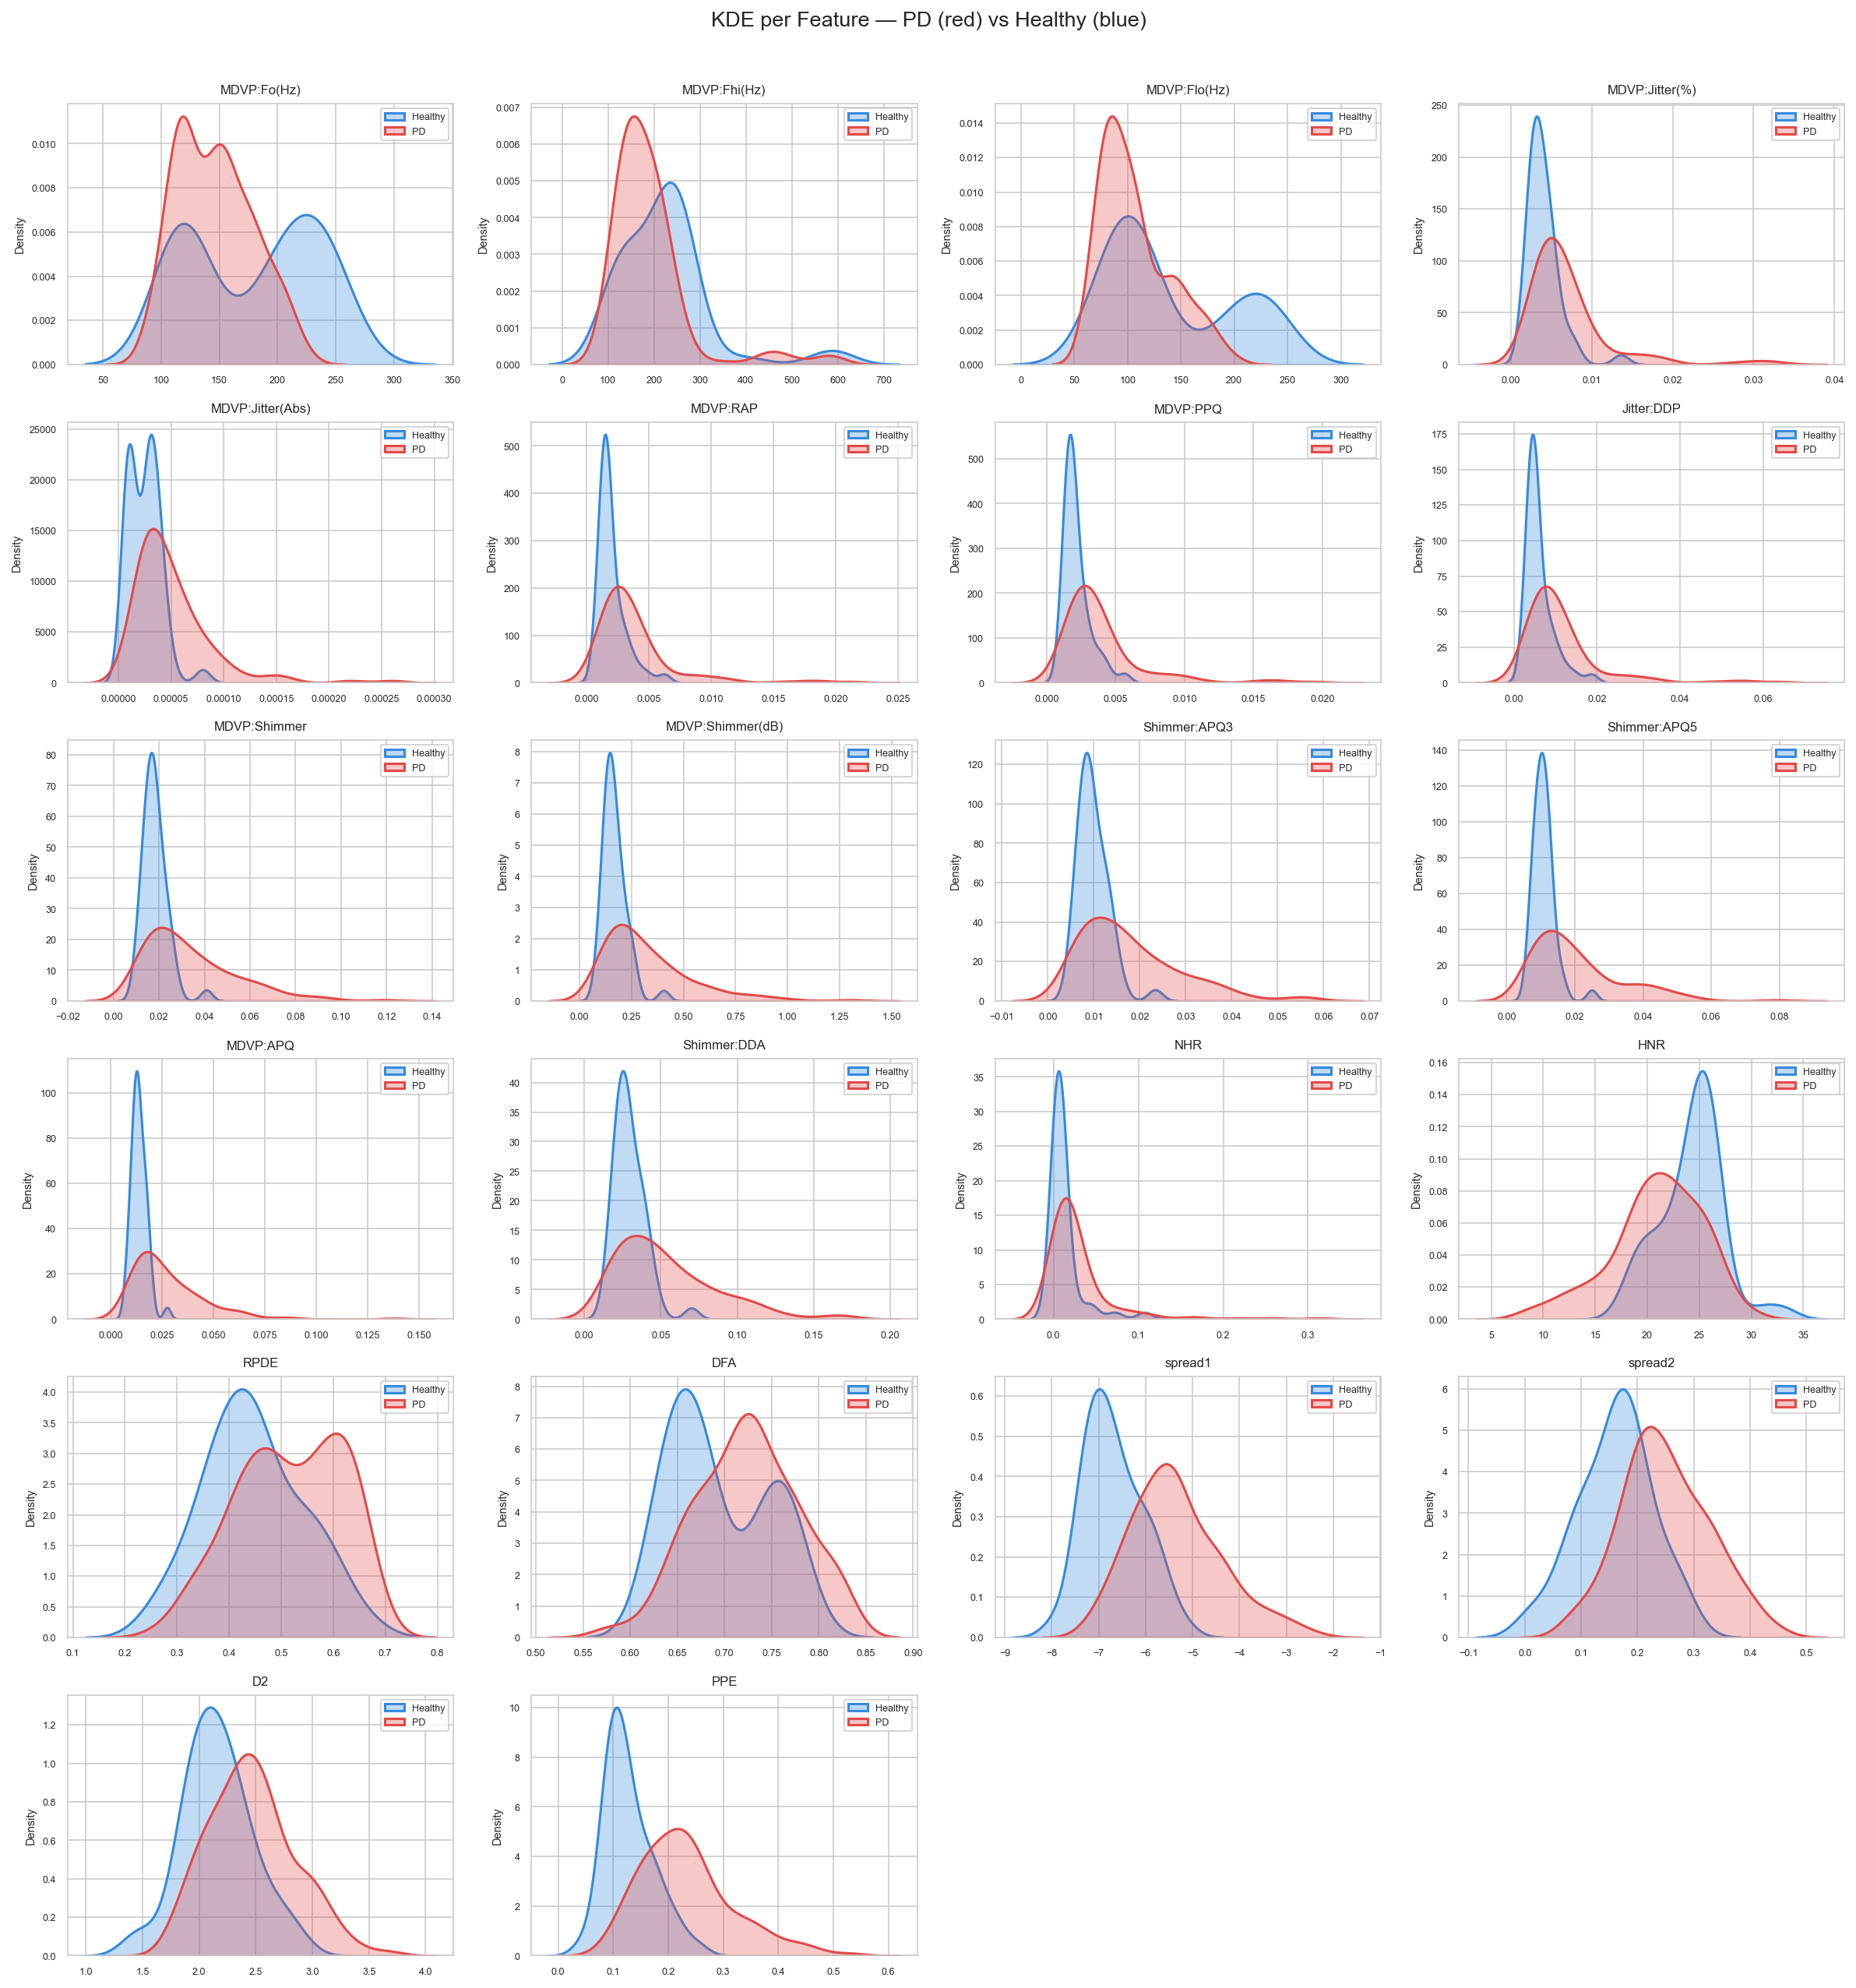

In [8]:
# KDE plots per feature, overlaid by group
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 2.8))
axes_flat = axes.flatten()

for i, feat in enumerate(features):
    ax = axes_flat[i]
    for g, label, color in [(0, 'Healthy', PALETTE["Healthy"]), (1, 'PD', PALETTE["PD"])]:
        vals = df.loc[df['status'] == g, feat].dropna()
        sns.kdeplot(vals, ax=ax, color=color, fill=True,
                    alpha=0.30, linewidth=1.5, label=label)
    ax.set_title(feat, fontsize=8)
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)

for j in range(len(features), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('KDE per Feature — PD (red) vs Healthy (blue)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/outlier_kde_by_group.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# Combined outlier flag (any of the three methods)
df['any_outlier'] = (
    (df['iqr_outlier_count'] >= 3) |
    df['zscore_outlier'] |
    df['pca_outlier']
)

print('Combined outlier summary')
print(f"  IQR (≥3 features):  {(df['iqr_outlier_count'] >= 3).sum()}")
print(f"  Z-score (|z|>3):    {df['zscore_outlier'].sum()}")
print(f"  PCA/Mahalanobis:    {df['pca_outlier'].sum()}")
print(f"  ANY of above:       {df['any_outlier'].sum()}")
print()
print('Breakdown by status:')
print(df.groupby(['status', 'any_outlier']).size().rename({0:'Healthy',1:'PD'}).unstack(fill_value=0))

Combined outlier summary
  IQR (≥3 features):  15
  Z-score (|z|>3):    14
  PCA/Mahalanobis:    5
  ANY of above:       21

Breakdown by status:
any_outlier  Healthy  PD
status                  
Healthy           42   2
PD               122  19


Outlier Sensitivity Test

To assess whether outlier recordings are driving our classification results we re-run
three lightweight classifiers on two versions of the data:

1. Full dataset
2. Outliers removed recordings flagged by any of the three detection methods excluded

Each classifier uses 5-fold GroupKFold (by subject) to prevent recording-level leakage
Primary metrics: Balanced Accuracy (accounts for the 75 / 25 class imbalance) and Macro F1

In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Log-transform the same skewed features as the modelling notebooks
LOG_FEATS = [
    'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA',
    'NHR', 'RPDE', 'D2', 'PPE',
]

def prepare_X(data, feats):
    X = data[feats].copy()
    for f in LOG_FEATS:
        if f in X.columns and (X[f] > 0).all():
            X[f] = np.log(X[f])
    return X.values

scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1_macro':          make_scorer(f1_score, average='macro', zero_division=0),
    'accuracy':          'accuracy',
}

classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, C=1)),
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale')),
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ]),
}

cv = GroupKFold(n_splits=5)

# Full dataset
X_full   = prepare_X(df, features)
y_full   = df['status'].values
grp_full = df['subject'].values

# Outlier-removed dataset
df_clean   = df[~df['any_outlier']].reset_index(drop=True)
X_clean    = prepare_X(df_clean, features)
y_clean    = df_clean['status'].values
grp_clean  = df_clean['subject'].values

n_out = df['any_outlier'].sum()
n_tot = len(df)
print(f'Full dataset  : {n_tot} recordings')
print(f'Outliers flagged: {n_out}  ({n_out/n_tot*100:.1f}% of recordings)')
print(f'After removal : {n_tot - n_out} recordings')
print(f'Outliers by status: {df.groupby("status")["any_outlier"].sum().to_dict()}')
print()

sens_results = {}
for name, clf in classifiers.items():
    cv_full  = cross_validate(clf, X_full,  y_full,  groups=grp_full,  cv=cv, scoring=scoring)
    cv_clean = cross_validate(clf, X_clean, y_clean, groups=grp_clean, cv=cv, scoring=scoring)
    sens_results[name] = {
        'full_ba':   cv_full['test_balanced_accuracy'].mean(),
        'full_f1':   cv_full['test_f1_macro'].mean(),
        'full_acc':  cv_full['test_accuracy'].mean(),
        'clean_ba':  cv_clean['test_balanced_accuracy'].mean(),
        'clean_f1':  cv_clean['test_f1_macro'].mean(),
        'clean_acc': cv_clean['test_accuracy'].mean(),
    }

print(f'  {"Model":<22} {"Full BA":>8} {"Clean BA":>9} {"Δ BA":>7}  {"Full F1":>8} {"Clean F1":>9} {"Δ F1":>7}')
print('  ' + '-'*78)
for name, r in sens_results.items():
    d_ba = r['clean_ba'] - r['full_ba']
    d_f1 = r['clean_f1'] - r['full_f1']
    flag_ba = ' !' if abs(d_ba) > 0.03 else ''
    flag_f1 = ' !' if abs(d_f1) > 0.03 else ''
    print(f'  {name:<22} {r["full_ba"]:>8.3f} {r["clean_ba"]:>9.3f} {d_ba:>+7.3f}{flag_ba}  {r["full_f1"]:>8.3f} {r["clean_f1"]:>9.3f} {d_f1:>+7.3f}{flag_f1}')


Full dataset  : 185 recordings
Outliers flagged: 21  (11.4% of recordings)
After removal : 164 recordings
Outliers by status: {0.0: 2, 1.0: 19}

  Model                   Full BA  Clean BA    Δ BA   Full F1  Clean F1    Δ F1
  ------------------------------------------------------------------------------
  Logistic Regression       0.728     0.666  -0.062 !     0.581     0.616  +0.035 !
  SVM (RBF)                 0.743     0.692  -0.051 !     0.589     0.646  +0.056 !
  Random Forest             0.740     0.678  -0.062 !     0.591     0.627  +0.036 !


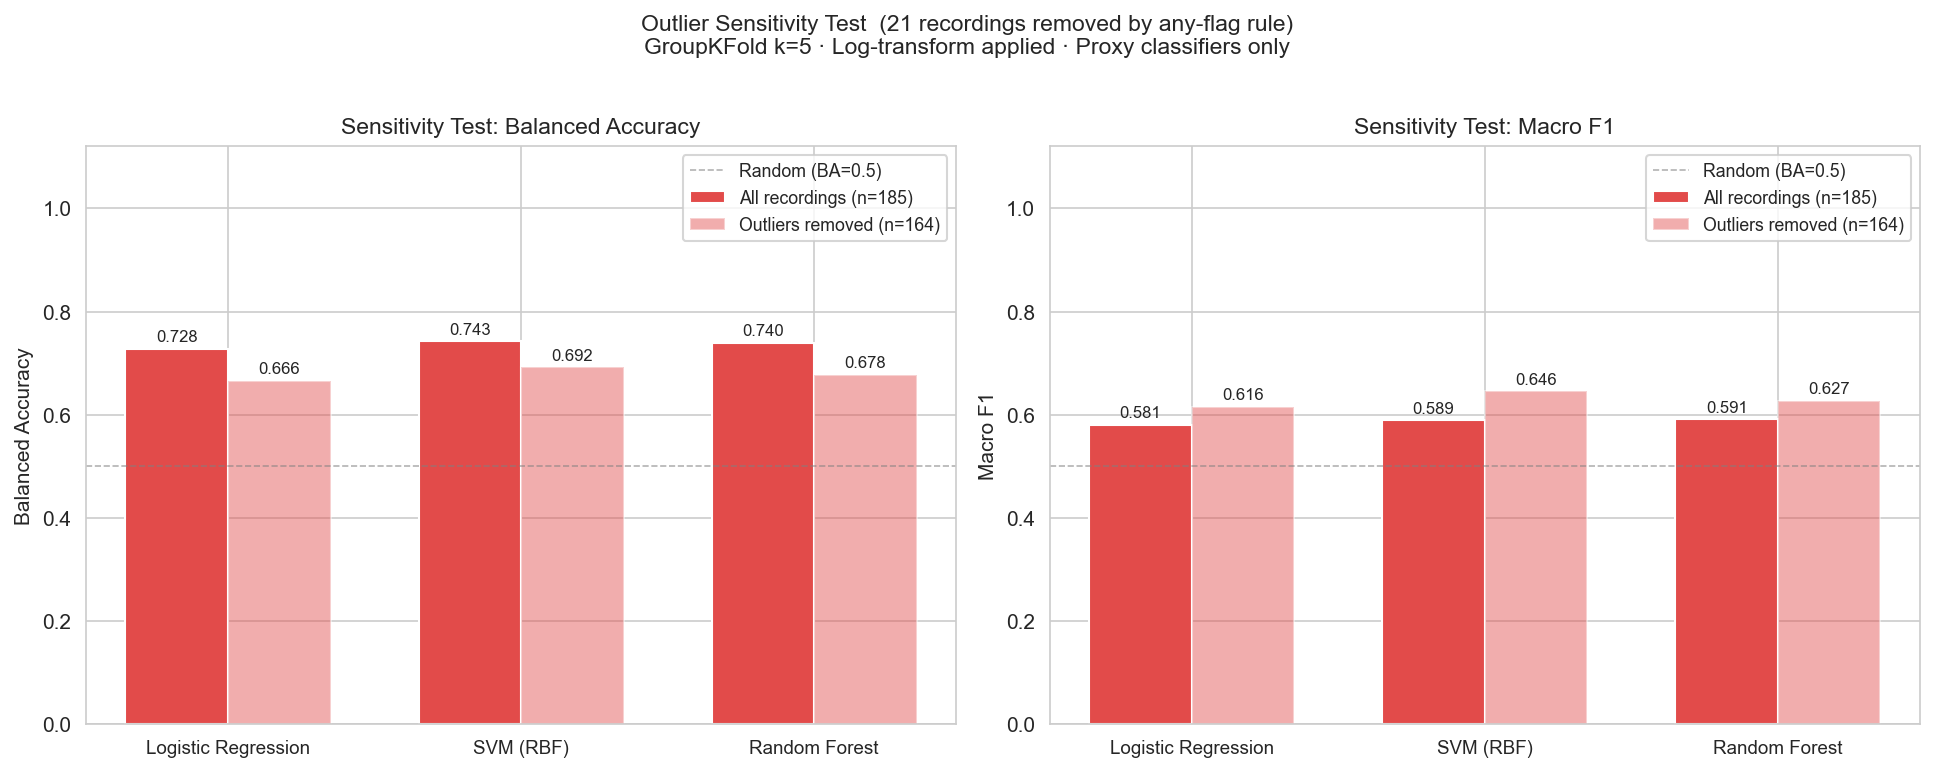

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_names = list(sens_results)
x     = np.arange(len(model_names))
width = 0.35

metric_pairs = [
    ('full_ba',  'clean_ba',  'Balanced Accuracy'),
    ('full_f1',  'clean_f1',  'Macro F1'),
]

for ax, (key_full, key_clean, title) in zip(axes, metric_pairs):
    vals_full  = [sens_results[m][key_full]  for m in model_names]
    vals_clean = [sens_results[m][key_clean] for m in model_names]

    b1 = ax.bar(x - width/2, vals_full,  width, label=f'All recordings (n={n_tot})',
                color=PALETTE["PD"], alpha=ALPHA_WITH, edgecolor='white')
    b2 = ax.bar(x + width/2, vals_clean, width, label=f'Outliers removed (n={n_tot-n_out})',
                color=PALETTE["PD"], alpha=ALPHA_WITHOUT, edgecolor='white')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

    ax.axhline(0.5,  color='grey',  linestyle='--', linewidth=0.8, alpha=0.6, label='Random (BA=0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f'Sensitivity Test: {title}', fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=8.5)

fig.suptitle(
    f'Outlier Sensitivity Test  ({n_out} recordings removed by any-flag rule)\n'
    f'GroupKFold k=5 · Log-transform applied · Proxy classifiers only',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('plots/outlier_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
